In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import cv2


In [2]:
SEED = 69
ENABLE_DETERMINISM = True

import os
os.environ['PYTHONHASHSEED'] = f'{SEED}'
os.environ['TF_DETERMINISTIC_OPS'] = f'{ENABLE_DETERMINISM}'
os.environ['TF_CUDNN_DETERMINISTIC'] = f'{ENABLE_DETERMINISM}'

import random
import numpy as np
import tensorflow as tf
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [3]:
!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
#!/bin/bash
!kaggle datasets download karimabdulnabi/fruit-classification10-class

Dataset URL: https://www.kaggle.com/datasets/karimabdulnabi/fruit-classification10-class
License(s): CC0-1.0
100% 29.2M/29.2M [00:02<00:00, 14.7MB/s]



In [5]:
import zipfile

with zipfile.ZipFile("/content/fruit-classification10-class.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/fruit-Image")

In [6]:
train_dir = "/content/fruit-Image/MY_data/train"
test_dir = "/content/fruit-Image/MY_data/test"

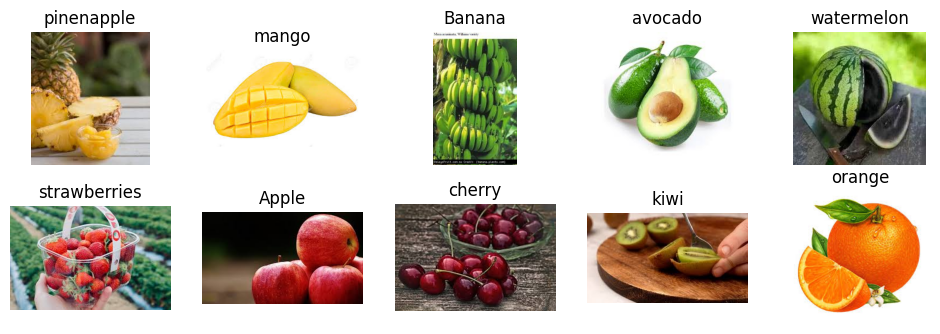

In [7]:
from numpy.random.mtrand import randn
classes = os.listdir(train_dir)
plt.figure(figsize=(12,10))
for i, cls in enumerate(classes):
  img_name = random.choice(os.listdir(os.path.join(train_dir,cls)))
  img_path = os.path.join(train_dir,cls,img_name)
  image = Image.open(img_path)
  plt.subplot(5,5,i+1)
  plt.imshow(image)
  plt.title(cls)
  plt.axis('off')
plt.show()


In [8]:
def data_count(data):
  class_count = {}
  for class_name in os.listdir(data):
    class_dir = os.path.join(data,class_name)
    count = len(os.listdir(class_dir))
    class_count[class_name] = count
  return class_count
print("Train class count: ",data_count(train_dir))
print("Test class count: ",data_count(test_dir))



Train class count:  {'pinenapple': 230, 'mango': 231, 'Banana': 230, 'avocado': 230, 'watermelon': 230, 'strawberries': 230, 'Apple': 230, 'cherry': 230, 'kiwi': 230, 'orange': 230}
Test class count:  {'pinenapple': 105, 'banana': 106, 'mango': 105, 'avocado': 105, 'apple': 89, 'stawberries': 103, 'watermelon': 105, 'cherry': 105, 'kiwi': 105, 'orange': 97}


In [9]:
def check_image_sizes(data_dir, num_samples=50):
    sizes = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        images = os.listdir(cls_path)
        sample_images = random.sample(images, min(num_samples, len(images)))

        for img_name in sample_images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    sizes.append(img.size)
            except:
                pass
    return sizes

sizes = check_image_sizes(train_dir)
unique_sizes = set(sizes)

print("Unique image sizes found:")
print(unique_sizes)

Unique image sizes found:
{(179, 282), (206, 244), (205, 246), (243, 208), (190, 266), (201, 251), (168, 299), (276, 183), (199, 253), (259, 194), (280, 180), (266, 190), (267, 189), (272, 185), (240, 180), (252, 200), (292, 172), (247, 204), (213, 236), (279, 181), (284, 177), (184, 273), (270, 187), (299, 168), (343, 147), (262, 192), (290, 174), (291, 173), (246, 205), (209, 241), (251, 201), (269, 188), (260, 194), (379, 133), (215, 235), (180, 180), (308, 164), (318, 159), (232, 217), (237, 213), (192, 263), (178, 282), (310, 163), (190, 265), (221, 228), (224, 224), (327, 154), (330, 153), (187, 269), (394, 128), (263, 191), (220, 229), (225, 225), (275, 183), (261, 193), (218, 231), (282, 179), (273, 185), (274, 184), (265, 190), (294, 171), (297, 170), (254, 199), (255, 198), (238, 212), (305, 165), (195, 259), (197, 256), (269, 187), (182, 277), (311, 162), (193, 261), (171, 295), (194, 260), (300, 168), (378, 133), (230, 219), (306, 165), (307, 164), (228, 221), (229, 220), (

In [10]:
# def avg_size(data_dir):
#     total_width = 0
#     total_height = 0
#     cnt = 0
#     for cls in os.listdir(data_dir):
#         cls_path = os.path.join(data_dir, cls)
#         images = os.listdir(cls_path)

#         for img_name in images:
#             img_path = os.path.join(cls_path, img_name)
#             try:
#                 with Image.open(img_path) as img:
#                     # img.size returns (width, height)
#                     total_width += img.size[0]
#                     total_height += img.size[1]
#                     cnt += 1
#             except:
#                 pass

#     return (total_width, total_height), cnt

# size, cnt = avg_size(train_dir)

# if cnt > 0:
#     avg_width = int(size[0] / cnt)
#     avg_height = int(size[1] / cnt)
#     print(f"Average image size: ({avg_width:.2f}, {avg_height:.2f})")
# else:
#     print("No images found or processed.")

In [11]:
def resize(data_dir):

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)
        images = os.listdir(cls_path)

        for img_name in images:
            img_path = os.path.join(cls_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img_resized = img.resize((256, 256))
                    img_resized.save(img_path)

            except:
                pass
resize(train_dir)
resize(test_dir)
sizes = check_image_sizes(train_dir)
unique_sizes = set(sizes)

print("Unique image sizes found:")
print(unique_sizes)

Unique image sizes found:
{(256, 256)}


In [12]:
def delete_not_rgb(data_dir):
    modes = set()
    rgb =0
    p=0
    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)
        images = os.listdir(cls_path)

        for img_name in images:
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    if img.mode == 'RGB':
                      rgb+=1
                    if img.mode == 'P':
                      os.remove(img_path)
                      p+=1

                    modes.add(img.mode)
            except:
                pass
    return modes,rgb,p

modes,rgb,p = delete_not_rgb(train_dir)
modes,rgb,p = delete_not_rgb(test_dir)

print("Image Modes:", modes)
print(rgb)
print(p)


Image Modes: {'RGB'}
1015
0


In [13]:
def check_formats(data_dir):
    formats = set()

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            ext = os.path.splitext(img_name)[1]
            formats.add(ext.lower())

    return formats

formats = check_formats(train_dir)
print("Image Formats:", formats)
formats = check_formats(test_dir)
print("Image Formats:", formats)

Image Formats: {'.jpeg'}
Image Formats: {'.jpeg'}


In [14]:
def find_corrupted_images(data_dir):
    corrupted = []

    for cls in os.listdir(data_dir):
        cls_path = os.path.join(data_dir, cls)

        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted.append(img_path)
                os.remove(img_path)

    return corrupted

corrupted_images = find_corrupted_images(train_dir)
corr = find_corrupted_images(test_dir)
print("Number of corrupted images:", len(corrupted_images))
print("Number of corrupted images:", len(corr))

Number of corrupted images: 16
Number of corrupted images: 10


In [32]:
import os
import tensorflow as tf

all_classes = sorted(os.listdir(train_dir))

train_paths, train_labels = [], []
val_paths,   val_labels   = [], []

for label_idx, class_name in enumerate(all_classes):
    class_dir = os.path.join(train_dir, class_name)
    images = sorted(os.listdir(class_dir))

    split = int(len(images) * 0.8)
    train_imgs = images[:split]
    val_imgs   = images[split:]

    for img in train_imgs:
        train_paths.append(os.path.join(class_dir, img))
        train_labels.append(label_idx)

    for img in val_imgs:
        val_paths.append(os.path.join(class_dir, img))
        val_labels.append(label_idx)

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    return img, label



In [33]:
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(load_image).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size =32
)

Found 1015 files belonging to 10 classes.


In [34]:
# class_names = train_ds.class_names
# print("Classes:", class_names)

In [51]:
data_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
])


In [59]:
def build_model(input_shape=(256,256,3), num_classes=10):

    inputs = layers.Input(shape=input_shape)

    # augmentation
    x = data_aug(inputs)

    # Normalize pixels
    x = layers.Rescaling(1./255)(x)

    # CNN
    x = layers.Conv2D(32, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D()(x)

    # x = layers.Conv2D(128, (3,3), padding='same')(x)
    # x = layers.BatchNormalization()(x)
    # x = layers.ReLU()(x)
    # x = layers.MaxPooling2D()(x)

    x = layers.GlobalMaxPooling2D()(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model


model = build_model(num_classes=10)
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_5 (Sequential)       │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 256, 256, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_25 (ReLU)                 │ (None, 256, 256, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_26 (ReLU)                 │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_27 (ReLU)                 │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95,434 (372.79 KB)

 Trainable params: 94,986 (371.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [60]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [61]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=5
    )
]

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 13s 169ms/step - accuracy: 0.3120 - loss: 2.3507 - val_accuracy: 0.1692 - val_loss: 6.1137 - learning_rate: 0.0100
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.3377 - loss: 1.9636 - val_accuracy: 0.1757 - val_loss: 2.5455 - learning_rate: 0.0100
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step - accuracy: 0.3624 - loss: 1.8815 - val_accuracy: 0.2777 - val_loss: 2.1376 - learning_rate: 0.0100
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.3936 - loss: 1.6971 - val_accuracy: 0.3948 - val_loss: 1.6010 - learning_rate: 0.0100
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 166ms/step - accuracy: 0.4073 - loss: 1.7551 - val_accuracy: 0.4078 - val_loss: 1.6293 - learning_rate: 0.0100
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - accuracy: 0.4446 - loss: 1.5985 - val_accuracy: 0.4013 - val_loss: 1.5474 - learning_rate: 0.0100
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 164ms/step - accuracy: 0.4770 - l

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Accuracy:", test_acc)

In [ ]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(acc,label="Train Accuracy")
plt.plot(val_acc,label="Validation Accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(loss,label="Train Loss")
plt.plot(val_loss,label="Validation Loss")
plt.legend()
plt.title("Loss")

plt.show()